# Bank Customer Intelligence System
## Unsupervised Learning: Customer Segmentation

This notebook prepares customer data, trains clustering algorithms, and evaluates customer segments using K-Means, Agglomerative Clustering, and DBSCAN.

## ## 1. Import Required Libraries1. Import Required Libraries

In [38]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    RobustScaler
)

from sklearn.cluster import KMeans

from sklearn.metrics import (
    davies_bouldin_score,
    silhouette_score
)

from sklearn.cluster import (
    AgglomerativeClustering
)

from sklearn.neighbors import (
    NearestNeighbors
)

from sklearn.cluster import DBSCAN

import joblib

## 2. Load the Dataset

In [2]:
DATA_PATH = Path("../dataset/bank-full.csv")

df = pd.read_csv(
    DATA_PATH,
    sep=";"
)

df.shape

(45211, 17)

## 3. Select Customer Features

In [3]:
clustering_features = [
    "age",
    "job",
    "marital",
    "education",
    "balance",
    "housing",
    "loan",
    "campaign"
]

clustering_df = df[
    clustering_features
].copy()

clustering_df.shape

(45211, 8)

In [4]:
clustering_df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'balance',
 'housing',
 'loan',
 'campaign']

## 4. Identify Feature Types

In [5]:
numerical_features = (
    clustering_df
    .select_dtypes(include="number")
    .columns
    .tolist()
)

categorical_features = (
    clustering_df
    .select_dtypes(include="object")
    .columns
    .tolist()
)

In [6]:
print("Numerical features:")
display(numerical_features)

print("Categorical features:")
display(categorical_features)

print(
    "Total features:",
    len(numerical_features)
    + len(categorical_features)
)

Numerical features:


['age', 'balance', 'campaign']

Categorical features:


['job', 'marital', 'education', 'housing', 'loan']

Total features: 8


## 5. Preprocess Customer Features

In [7]:
numerical_transformer = Pipeline(
    steps=[
        (
            "scaler",
            RobustScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [8]:
clustering_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

clustering_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [9]:
X_cluster = (
    clustering_preprocessor
    .fit_transform(clustering_df)
)

X_cluster.shape

(45211, 26)

In [10]:
# print(df.head())

In [11]:
transformed_feature_names = (
    clustering_preprocessor
    .get_feature_names_out()
)

transformed_feature_names

array(['numerical__age', 'numerical__balance', 'numerical__campaign',
       'categorical__job_admin.', 'categorical__job_blue-collar',
       'categorical__job_entrepreneur', 'categorical__job_housemaid',
       'categorical__job_management', 'categorical__job_retired',
       'categorical__job_self-employed', 'categorical__job_services',
       'categorical__job_student', 'categorical__job_technician',
       'categorical__job_unemployed', 'categorical__job_unknown',
       'categorical__marital_divorced', 'categorical__marital_married',
       'categorical__marital_single', 'categorical__education_primary',
       'categorical__education_secondary',
       'categorical__education_tertiary',
       'categorical__education_unknown', 'categorical__housing_no',
       'categorical__housing_yes', 'categorical__loan_no',
       'categorical__loan_yes'], dtype=object)

In [12]:
print(
    "Contains NaN:",
    np.isnan(X_cluster).any()
)

print(
    "Contains infinite values:",
    np.isinf(X_cluster).any()
)

Contains NaN: False
Contains infinite values: False


## 6. K-Means Clustering
### 6.1 Elbow Method

In [13]:
k_values = range(2, 11)
inertia_values = []

for k in k_values:
    kmeans_model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    kmeans_model.fit(X_cluster)

    inertia_values.append(
        kmeans_model.inertia_
    )

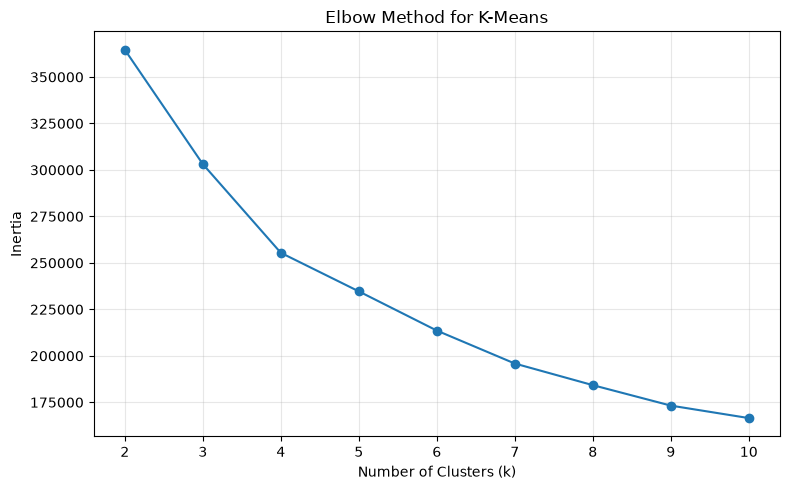

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 K-Means Cluster Evaluation

In [15]:
kmeans_evaluation = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    labels = model.fit_predict(X_cluster)

    silhouette = silhouette_score(
        X_cluster,
        labels,
        sample_size=5000,
        random_state=42
    )

    davies_bouldin = davies_bouldin_score(
        X_cluster,
        labels
    )

    kmeans_evaluation.append({
        "k": k,
        "Silhouette Score": silhouette,
        "Davies-Bouldin Index": davies_bouldin
    })

kmeans_evaluation_df = pd.DataFrame(
    kmeans_evaluation
)

kmeans_evaluation_df.round(4)

,k,Silhouette Score,Davies-Bouldin Index
0,2,0.5968,0.8302
1,3,0.5155,0.8611
2,4,0.4144,0.9355
3,5,0.1940,1.3133
4,6,0.1940,1.2424
5,7,0.1501,1.4048
6,8,0.1469,1.3801
7,9,0.1446,1.4004
8,10,0.1395,1.4123


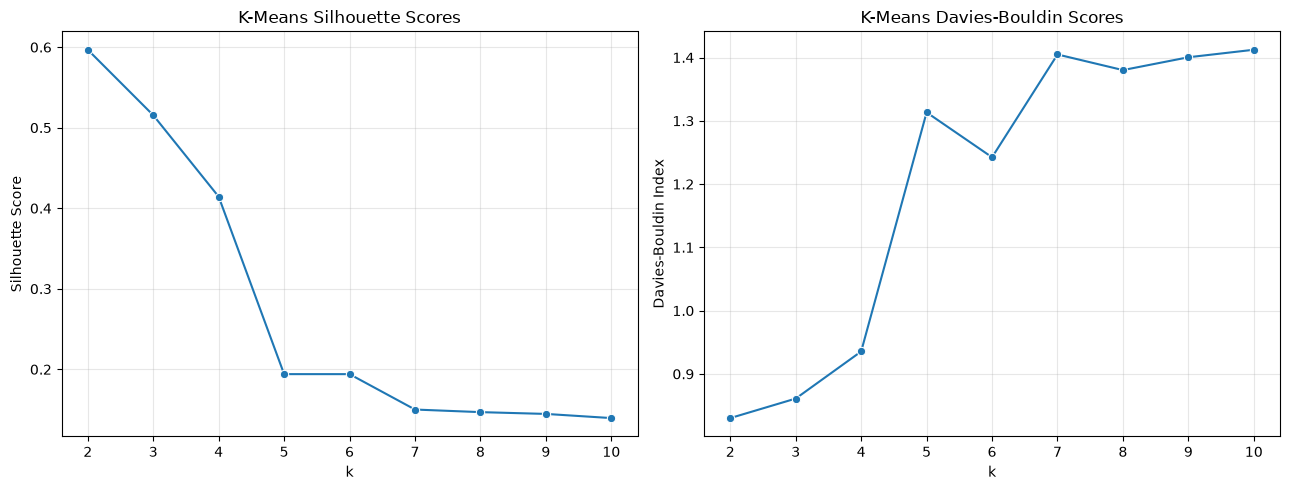

In [16]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

sns.lineplot(
    data=kmeans_evaluation_df,
    x="k",
    y="Silhouette Score",
    marker="o",
    ax=axes[0]
)

axes[0].set_title(
    "K-Means Silhouette Scores"
)
axes[0].set_xticks(list(k_values))
axes[0].grid(alpha=0.3)

sns.lineplot(
    data=kmeans_evaluation_df,
    x="k",
    y="Davies-Bouldin Index",
    marker="o",
    ax=axes[1]
)

axes[1].set_title(
    "K-Means Davies-Bouldin Scores"
)
axes[1].set_xticks(list(k_values))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### K-Means Cluster Selection

The Elbow Method suggested approximately four clusters. However, `k=2` achieved the highest Silhouette Score of **0.5968** and the lowest Davies-Bouldin Index of **0.8302**. Based on the evaluation criteria defined in the proposal, two clusters were selected for the final K-Means model.

In [17]:
selected_k = 2

final_kmeans_model = KMeans(
    n_clusters=selected_k,
    n_init=10,
    random_state=42
)

kmeans_labels = (
    final_kmeans_model
    .fit_predict(X_cluster)
)

In [18]:
kmeans_results_df = (
    clustering_df.copy()
)

kmeans_results_df["cluster"] = (
    kmeans_labels
)

In [19]:
kmeans_cluster_sizes = (
    kmeans_results_df["cluster"]
    .value_counts()
    .sort_index()
)

kmeans_cluster_percentages = (
    kmeans_results_df["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_size_summary = pd.DataFrame({
    "Customer Count": kmeans_cluster_sizes,
    "Percentage": kmeans_cluster_percentages
})

cluster_size_summary

,Customer Count,Percentage
cluster,,
0,43316,95.81
1,1895,4.19


### 6.3 K-Means Cluster Profiles

In [20]:
numerical_cluster_profile = (
    kmeans_results_df
    .groupby("cluster")[numerical_features]
    .agg(["mean", "median"])
    .round(2)
)

numerical_cluster_profile

age          balance         campaign       
          mean median      mean  median     mean median
cluster                                                
0        40.81   39.0    899.98   405.0     2.77    2.0
1        43.79   42.0  11929.27  9252.0     2.67    2.0

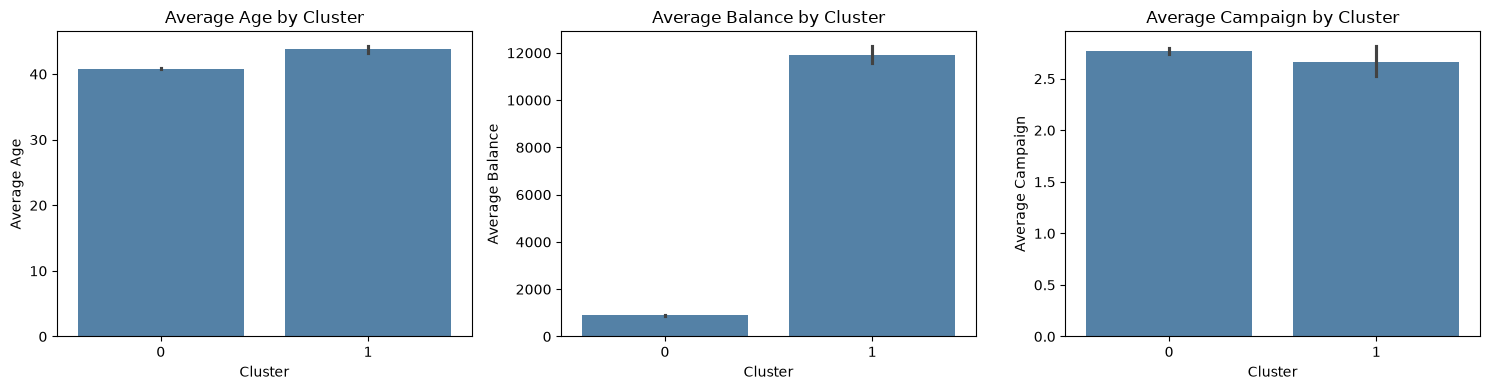

In [21]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for index, feature in enumerate(
    numerical_features
):
    sns.barplot(
        data=kmeans_results_df,
        x="cluster",
        y=feature,
        ax=axes[index],
        color="steelblue"
    )

    axes[index].set_title(
        f"Average {feature.capitalize()} by Cluster"
    )
    axes[index].set_xlabel("Cluster")
    axes[index].set_ylabel(
        f"Average {feature.capitalize()}"
    )

plt.tight_layout()
plt.show()

#### Numerical Cluster Findings

- Cluster 0 contains 95.81% of customers and represents customers with typical account balances.
- Cluster 1 contains 4.19% of customers and represents a smaller high-balance segment.
- Cluster 1 customers are slightly older on average.
- Campaign contact frequency is similar between the two clusters.
- Account balance is the main numerical characteristic separating the clusters.

In [22]:
categorical_profile_rows = []

for cluster_id, cluster_data in (
    kmeans_results_df.groupby("cluster")
):
    profile = {
        "cluster": cluster_id
    }

    for feature in categorical_features:
        category_counts = (
            cluster_data[feature]
            .value_counts(normalize=True)
        )

        dominant_category = (
            category_counts.index[0]
        )

        dominant_percentage = (
            category_counts.iloc[0] * 100
        )

        profile[feature] = (
            f"{dominant_category} "
            f"({dominant_percentage:.1f}%)"
        )

    categorical_profile_rows.append(
        profile
    )

categorical_cluster_profile = pd.DataFrame(
    categorical_profile_rows
).set_index("cluster")

categorical_cluster_profile

,job,marital,education,housing,loan
cluster,,,,,
0,blue-collar (21.8%),married (60.0%),secondary (51.9%),yes (56.1%),no (83.5%)
1,management (31.6%),married (64.3%),tertiary (43.9%),no (55.9%),no (94.3%)


#### Categorical Cluster Findings

- Cluster 0 is dominated by blue-collar, married, and secondary-educated customers.
- Most Cluster 0 customers have housing loans but do not have personal loans.
- Cluster 1 is dominated by management, married, and tertiary-educated customers.
- Most Cluster 1 customers do not have housing or personal loans.
- Cluster 1 represents a smaller, financially stronger professional customer segment.

In [23]:
cluster_subscription_analysis = pd.crosstab(
    kmeans_labels,
    df["y"],
    normalize="index"
).mul(100).round(2)

cluster_subscription_analysis.index.name = (
    "cluster"
)

cluster_subscription_analysis

y,no,yes
cluster,,
0,88.47,11.53
1,84.49,15.51


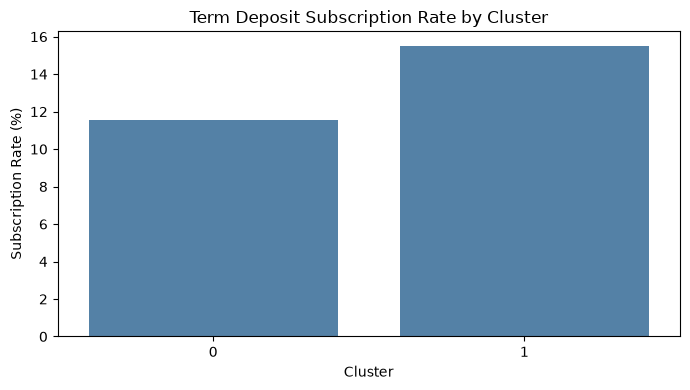

In [24]:
subscription_plot_data = (
    cluster_subscription_analysis["yes"]
    .reset_index()
    .rename(
        columns={
            "yes": "Subscription Rate"
        }
    )
)

plt.figure(figsize=(7, 4))

sns.barplot(
    data=subscription_plot_data,
    x="cluster",
    y="Subscription Rate",
    color="steelblue"
)

plt.title(
    "Term Deposit Subscription Rate by Cluster"
)
plt.xlabel("Cluster")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.show()

#### Subscription Behavior by Cluster

- Cluster 1 has a higher term-deposit subscription rate than Cluster 0.
- The smaller high-balance professional segment appears more responsive to term-deposit campaigns.
- The target variable was used only for post-clustering analysis and was not used to create the customer clusters.

## 7. Agglomerative Clustering
### 7.1 Prepare a Representative Evaluation Sample

In [25]:
evaluation_sample_size = 5000

random_generator = np.random.default_rng(
    seed=42
)

sample_indices = random_generator.choice(
    X_cluster.shape[0],
    size=evaluation_sample_size,
    replace=False
)

X_cluster_sample = X_cluster[
    sample_indices
]

X_cluster_sample.shape

(5000, 26)

In [26]:
agglomerative_model = (
    AgglomerativeClustering(
        n_clusters=selected_k,
        linkage="ward"
    )
)

agglomerative_labels = (
    agglomerative_model
    .fit_predict(X_cluster_sample)
)

In [27]:
agglomerative_cluster_sizes = (
    pd.Series(
        agglomerative_labels,
        name="cluster"
    )
    .value_counts()
    .sort_index()
)

agglomerative_cluster_sizes

cluster
0    4942
1      58
Name: count, dtype: int64

In [28]:
agglomerative_silhouette = (
    silhouette_score(
        X_cluster_sample,
        agglomerative_labels
    )
)

agglomerative_davies_bouldin = (
    davies_bouldin_score(
        X_cluster_sample,
        agglomerative_labels
    )
)

print(
    "Agglomerative Silhouette Score:",
    round(agglomerative_silhouette, 4)
)

print(
    "Agglomerative Davies-Bouldin Index:",
    round(
        agglomerative_davies_bouldin,
        4
    )
)

Agglomerative Silhouette Score: 0.7265
Agglomerative Davies-Bouldin Index: 0.5661


### 7.2 Agglomerative Clustering Findings

- Agglomerative Clustering produced two highly imbalanced clusters.
- Cluster 0 contains 4,942 sampled customers, while Cluster 1 contains only 58.
- It achieved a Silhouette Score of **0.7265**.
- It achieved a Davies-Bouldin Index of **0.5661**.
- Although the internal metrics are strong, the very small second cluster may mainly represent extreme customers rather than a broad business segment.
- Agglomerative Clustering does not directly support prediction for new customers.

## 8. DBSCAN Clustering
### 8.1 Select the DBSCAN Distance Threshold

In [29]:
minimum_samples = 10

nearest_neighbors = NearestNeighbors(
    n_neighbors=minimum_samples
)

nearest_neighbors.fit(
    X_cluster_sample
)

neighbor_distances, _ = (
    nearest_neighbors.kneighbors(
        X_cluster_sample
    )
)

k_distances = np.sort(
    neighbor_distances[:, -1]
)

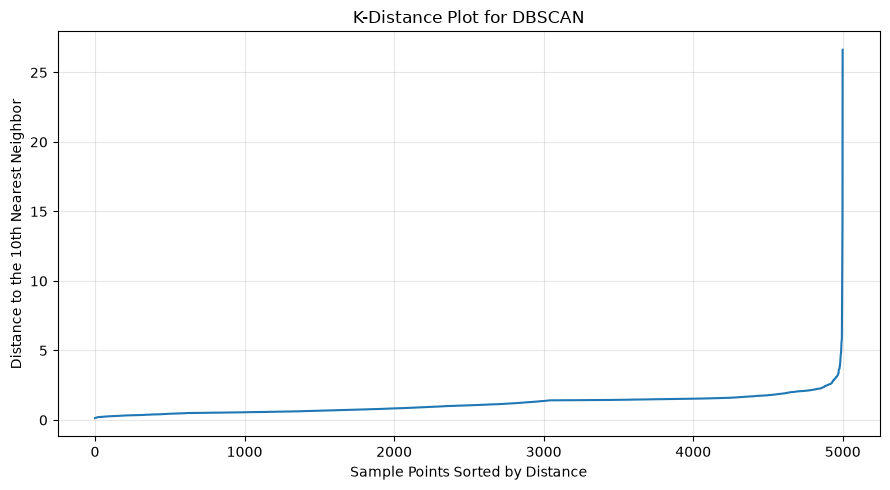

In [30]:
plt.figure(figsize=(9, 5))

plt.plot(k_distances)

plt.title(
    "K-Distance Plot for DBSCAN"
)
plt.xlabel(
    "Sample Points Sorted by Distance"
)
plt.ylabel(
    "Distance to the 10th Nearest Neighbor"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
eps_values = [
    1.5,
    2.0,
    2.5,
    3.0,
    3.5
]

dbscan_evaluation = []

for eps in eps_values:
    model = DBSCAN(
        eps=eps,
        min_samples=minimum_samples
    )

    labels = model.fit_predict(
        X_cluster_sample
    )

    unique_labels = set(labels)

    number_of_clusters = len(
        unique_labels - {-1}
    )

    noise_count = (
        labels == -1
    ).sum()

    noise_percentage = (
        noise_count
        / len(labels)
        * 100
    )

    non_noise_mask = labels != -1
    non_noise_labels = labels[
        non_noise_mask
    ]

    if len(set(non_noise_labels)) >= 2:
        silhouette = silhouette_score(
            X_cluster_sample[
                non_noise_mask
            ],
            non_noise_labels
        )

        davies_bouldin = (
            davies_bouldin_score(
                X_cluster_sample[
                    non_noise_mask
                ],
                non_noise_labels
            )
        )
    else:
        silhouette = np.nan
        davies_bouldin = np.nan

    dbscan_evaluation.append({
        "eps": eps,
        "Clusters": number_of_clusters,
        "Noise Percentage": noise_percentage,
        "Silhouette Score": silhouette,
        "Davies-Bouldin Index": davies_bouldin
    })

dbscan_evaluation_df = pd.DataFrame(
    dbscan_evaluation
)

dbscan_evaluation_df.round(4)

,eps,Clusters,Noise Percentage,Silhouette Score,Davies-Bouldin Index
0,1.5,1,11.90,NaN,NaN
1,2.0,2,3.36,0.6328,0.3789
2,2.5,1,1.20,NaN,NaN
3,3.0,1,0.54,NaN,NaN
4,3.5,1,0.28,NaN,NaN


### 8.2 DBSCAN Parameter Selection

An `eps` value of **2.0** was selected because it produced two clusters with only **3.36%** noise. It achieved a Silhouette Score of **0.6328** and a Davies-Bouldin Index of **0.3789**. Other tested `eps` values produced only one cluster and could not be evaluated using the selected clustering metrics.

In [32]:
selected_eps = 2.0

final_dbscan_model = DBSCAN(
    eps=selected_eps,
    min_samples=minimum_samples
)

dbscan_labels = (
    final_dbscan_model
    .fit_predict(X_cluster_sample)
)

In [33]:
dbscan_cluster_sizes = (
    pd.Series(
        dbscan_labels,
        name="cluster"
    )
    .value_counts()
    .sort_index()
)

dbscan_cluster_sizes

cluster
-1     168
 0    4824
 1       8
Name: count, dtype: int64

In [34]:
dbscan_cluster_percentages = (
    pd.Series(dbscan_labels)
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

dbscan_size_summary = pd.DataFrame({
    "Customer Count": dbscan_cluster_sizes,
    "Percentage": dbscan_cluster_percentages
})

dbscan_size_summary

,Customer Count,Percentage
-1,168,3.36
0,4824,96.48
1,8,0.16


### 8.3 DBSCAN Findings

- DBSCAN identified 168 customers as noise.
- The main cluster contains 4,824 sampled customers.
- The second cluster contains only 8 customers.
- Although DBSCAN achieved strong internal scores, the second cluster is too small to represent a broad and actionable customer segment.
- DBSCAN does not directly support assigning new customers to clusters through a standard `predict()` method.

In [35]:
sample_kmeans_model = KMeans(
    n_clusters=selected_k,
    n_init=10,
    random_state=42
)

sample_kmeans_labels = (
    sample_kmeans_model
    .fit_predict(X_cluster_sample)
)

sample_kmeans_silhouette = (
    silhouette_score(
        X_cluster_sample,
        sample_kmeans_labels
    )
)

sample_kmeans_davies_bouldin = (
    davies_bouldin_score(
        X_cluster_sample,
        sample_kmeans_labels
    )
)

In [36]:
dbscan_non_noise_mask = (
    dbscan_labels != -1
)

dbscan_silhouette = silhouette_score(
    X_cluster_sample[
        dbscan_non_noise_mask
    ],
    dbscan_labels[
        dbscan_non_noise_mask
    ]
)

dbscan_davies_bouldin = (
    davies_bouldin_score(
        X_cluster_sample[
            dbscan_non_noise_mask
        ],
        dbscan_labels[
            dbscan_non_noise_mask
        ]
    )
)

In [37]:
algorithm_comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Agglomerative",
        "DBSCAN"
    ],
    "Silhouette Score": [
        sample_kmeans_silhouette,
        agglomerative_silhouette,
        dbscan_silhouette
    ],
    "Davies-Bouldin Index": [
        sample_kmeans_davies_bouldin,
        agglomerative_davies_bouldin,
        dbscan_davies_bouldin
    ],
    "Smallest Cluster Size": [
        pd.Series(
            sample_kmeans_labels
        ).value_counts().min(),
        pd.Series(
            agglomerative_labels
        ).value_counts().min(),
        pd.Series(
            dbscan_labels[
                dbscan_labels != -1
            ]
        ).value_counts().min()
    ],
    "Noise Percentage": [
        0.0,
        0.0,
        3.36
    ]
}).set_index("Algorithm")

algorithm_comparison.round(4)

,Silhouette Score,Davies-Bouldin Index,Smallest Cluster Size,Noise Percentage
Algorithm,,,,
K-Means,0.5474,0.9250,275,0.00
Agglomerative,0.7265,0.5661,58,0.00
DBSCAN,0.6328,0.3789,8,3.36


## 9. Final Clustering Model Selection

Agglomerative Clustering achieved the highest Silhouette Score of **0.7265**, while DBSCAN achieved the lowest Davies-Bouldin Index of **0.3789**. However, Agglomerative produced a second cluster containing only 58 sampled customers, and DBSCAN produced a second cluster containing only 8 customers while labeling 3.36% as noise.

K-Means produced the most actionable customer segmentation, with a smallest sample cluster of 275 customers and a full-data high-balance segment of 1,895 customers. It also supports assigning new customers to clusters using `predict()`, which is required by the proposed `/cluster` API endpoint.

Therefore, **K-Means with two clusters** was selected as the final deployable clustering model.

In [39]:
final_clustering_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clustering_preprocessor
        ),
        (
            "clusterer",
            KMeans(
                n_clusters=selected_k,
                n_init=10,
                random_state=42
            )
        )
    ]
)

final_clustering_pipeline.fit(
    clustering_df
)

print(
    "Final clustering model training completed."
)

Final clustering model training completed.


In [40]:
MODEL_DIR = Path("../backend/models")

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

clustering_model_path = (
    MODEL_DIR / "clustering_model.pkl"
)

joblib.dump(
    final_clustering_pipeline,
    clustering_model_path
)

print(
    "Clustering model saved:",
    clustering_model_path.exists()
)

Clustering model saved: True


## 10. Clustering Summary

- The clustering analysis used 45,211 customer records.
- The target column `y` was excluded from clustering training.
- The `duration` feature was excluded to remain consistent with the deployment design.
- Eight customer features were used to match the proposed `/cluster` API input.
- Numerical features were transformed using RobustScaler.
- Categorical features were transformed using OneHotEncoder.
- K-Means, Agglomerative Clustering, and DBSCAN were evaluated.
- The Elbow Method suggested approximately four clusters, but two clusters achieved the strongest K-Means internal evaluation scores.
- Agglomerative Clustering achieved the highest Silhouette Score of 0.7265 but produced a very small second cluster.
- DBSCAN achieved the lowest Davies-Bouldin Index of 0.3789 but produced a second cluster containing only 8 sampled customers and labeled 3.36% as noise.
- K-Means produced the most actionable and deployable customer segmentation.
- Cluster 0 contains 43,316 customers with typical account balances.
- Cluster 1 contains 1,895 customers with significantly higher account balances.
- Cluster 0 is dominated by blue-collar, married, secondary-educated customers, and many have housing loans.
- Cluster 1 is dominated by management, married, tertiary-educated customers, and most do not have housing or personal loans.
- Cluster 1 has a higher term-deposit subscription rate than Cluster 0.
- K-Means with two clusters was selected as the final deployable clustering model.
- The complete preprocessing and K-Means pipeline was saved as `backend/models/clustering_model.pkl`.